# Classificação com Support Vector Machines (SVM)
**Gustavo Pereira Prado** **|** **11241104195**


**Objetivo**: Realizar o carregamento e limpeza inicial dos dados (remoção de identificadores irrelevantes como id e tratamento de colunas vazias, se houver).

## **1. Importação das bibliotecas + Carregamento de Dados:**

In [1]:
# Importação de bibliotecas
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style = "whitegrid")
plt.rcParams["figure.figsize"] = (5, 4)

# Carregamento de dados
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        # Impressão somente do arquivo '.csv', excluindo o arquivo '.sqlite'
        if filename.endswith('.csv'):
            print(f'Arquivo com os dados:{os.path.join(dirname, filename)}')

dataFrame = pd.read_csv('/kaggle/input/datasets/uciml/breast-cancer-wisconsin-data/data.csv')

print(f'Dimensão do dataset: {dataFrame.shape}\n\nDistribuição dos diagnósticos: {dataFrame['diagnosis'].value_counts()}')
dataFrame.head()

Arquivo com os dados:/kaggle/input/datasets/uciml/breast-cancer-wisconsin-data/data.csv
Dimensão do dataset: (569, 33)

Distribuição dos diagnósticos: diagnosis
B    357
M    212
Name: count, dtype: int64


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## **2. Análise Exploratória de Dados (EDA, do inglês Exploratory Data Analysis)**:

In [2]:
# Quantas linhas e colunas possui o DataFrame + outras informações
print(f'=Dimensão do DataFrame\n {dataFrame.shape}\n\n=Informações Gerais')
print(dataFrame.info())

# Verificar a coluna 'diagnosis', pois essa coluna contém nossos rótulos
print(f'\n=Contagem')
print(dataFrame['diagnosis'].value_counts())

# Remoção da coluna 'id'
if 'id'in dataFrame.columns:
    dataFrame = dataFrame.drop(columns =['id'])

# Remoção de colunas vazias
dataFrame = dataFrame.dropna(how = 'all', axis = 1)

# M = 1 (maligno), B = 0 (benigno)
dataFrame['diagnosis_encoded'] = dataFrame['diagnosis'].map({'M': 1, 'B': 0})

# Após fazer a EDA.
print(f'\n=Dimensão do DataFrame pós EDA\n {dataFrame.shape}\n\n=Informações Gerais')


=Dimensão do DataFrame
 (569, 33)

=Informações Gerais
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               

## **3. Divisão e padronização dos dados**:

In [3]:
# Separação das Características e Rótulos
caract = dataFrame.drop(columns = ['diagnosis', 'diagnosis_encoded'])
rotulo = dataFrame['diagnosis_encoded']

# Divisão de treino (80%) e teste (20%)
caract_train, caract_test, rotulo_train, rotulo_test = train_test_split(
    caract,
    rotulo,
    test_size = 0.2,
    random_state = 42,
    stratify = rotulo
)

print(f'Formato X treino: {caract_train.shape}\nFormato X treino: {caract_test.shape}')

Formato X treino: (455, 30)
Formato X treino: (114, 30)


## **4. Modelagem SVM**

In [4]:
# SVM Linear
pipelineSVMlinear = Pipeline([
    ('scalter', StandardScaler()),
    ('svm', SVC(kernel = 'linear', C = 1.0, random_state = 42))
])

pipelineSVMlinear.fit(caract_train, rotulo_train)
rotulo_pred_linear = pipelineSVMlinear.predict(caract_test)

acc_linear = accuracy_score(rotulo_test, rotulo_pred_linear)

print(f"Acurácia do SVM linear: {acc_linear:.4f}\n\nRelatório de classificação SVM linear\n")
print(classification_report(rotulo_test, rotulo_pred_linear))

Acurácia do SVM linear: 0.9649

Relatório de classificação SVM linear

              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



In [5]:
# SVM Não Linear com kernel RBF
pipelineSVM_RBF = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel = 'rbf', C = 1.0, gamma = 'scale', random_state = 42))
])

pipelineSVM_RBF.fit(caract_train, rotulo_train)
rotulo_pred_rbf = pipelineSVM_RBF.predict(caract_test)

acc_rbf = accuracy_score(rotulo_test, rotulo_pred_rbf)
print(f"Acurácia do SVM com kernel RBF: {acc_rbf:.4f}\n\nRelatório de classificação SVM com kernel RBF\n")
print(classification_report(rotulo_test, rotulo_pred_rbf))

Acurácia do SVM com kernel RBF: 0.9737

Relatório de classificação SVM com kernel RBF

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



## **5. Ajuste de Hiperparâmetros**

In [6]:
param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1]
}

grid_search = GridSearchCV(pipelineSVM_RBF, param_grid, cv = 5, scoring = 'accuracy')
grid_search.fit(caract_train, rotulo_train)

print('Melhores hiperparâmetros encontrados:')
print(grid_search.best_params_)

best_model = grid_search.best_estimator_
rotulo_pred_best = best_model.predict(caract_test)

Melhores hiperparâmetros encontrados:
{'svm__C': 1, 'svm__gamma': 'scale'}


## **6. Avaliação de desempenho**

Relatório do Melhor Modelo:

              precision    recall  f1-score   support

 Benigno (B)       0.96      1.00      0.98        72
 Maligno (M)       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



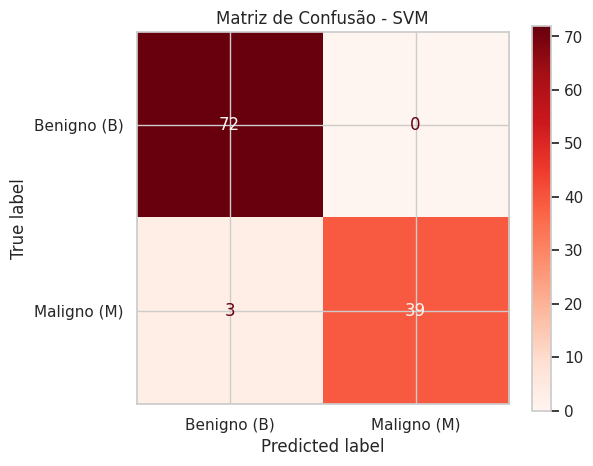

In [7]:
print('Relatório do Melhor Modelo:\n')
print(classification_report(rotulo_test, rotulo_pred_best, target_names = ['Benigno (B)', 'Maligno (M)']))

# Matriz de confusão
fig, ax = plt.subplots(figsize = (6, 5))
ConfusionMatrixDisplay.from_predictions(
    rotulo_test, rotulo_pred_best,
    display_labels = ['Benigno (B)', 'Maligno (M)'],
    cmap = 'Reds', ax = ax
)

plt.title('Matriz de Confusão - SVM')
plt.show()